In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
extotw = pd.read_table('data/estat_tour_dem_extotw.tsv')
tnac = pd.read_table('data/estat_tour_dem_tnac.tsv')
ttw = pd.read_table('data/estat_tour_dem_ttw.tsv')
tnw = pd.read_table('data/estat_tour_dem_tnw.tsv')
arnraw = pd.read_table('data/estat_tour_occ_arnraw.tsv')
ttws = pd.read_table('data/estat_tour_dem_ttws.tsv')
tnws = pd.read_table('data/estat_tour_dem_tnws.tsv')

In [60]:
def clean_df(df, dropna=False):
    df = df.copy()
    columns = df.columns
    new_columns = columns[0].split(',')
    
    n_col = df[columns[0]].str.split(',', expand=True)
    n_col.columns = new_columns
    df = pd.concat([n_col, df], axis=1)
    df = df.drop(columns=[columns[0]])
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace(':', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('u', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('b', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('e', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: pd.to_numeric(s, errors='coerce'))
    if dropna:
        df = df.dropna()
    return df, columns[1:]

In [66]:
extotw_cleaned, years_extotw = clean_df(extotw, dropna=True)
tnac_cleaned, years_tnac = clean_df(tnac, dropna=True)
ttw_cleaned, years_ttw = clean_df(ttw, dropna=True)
tnw_cleaned, years_tnw = clean_df(tnw, dropna=True)
arnraw_cleaned, years_arnraw = clean_df(arnraw, dropna=True)
ttws_cleaned, years_ttws = clean_df(ttws, dropna=True)
tnws_cleaned, years_tnws = clean_df(tnws, dropna=True)


# Save cleaned dataframes to new CSV files
extotw_cleaned.to_csv('data/cleaned_extotw.csv', index=False)
tnac_cleaned.to_csv('data/cleaned_tnac.csv', index=False)
ttw_cleaned.to_csv('data/cleaned_ttw.csv', index=False)
tnw_cleaned.to_csv('data/cleaned_tnw.csv', index=False)
arnraw_cleaned.to_csv('data/cleaned_arnraw.csv', index=False)
ttws_cleaned.to_csv('data/cleaned_ttws.csv', index=False)
tnws_cleaned.to_csv('data/cleaned_tnws.csv', index=False)

eu_countries = extotw_cleaned['geo'].unique()

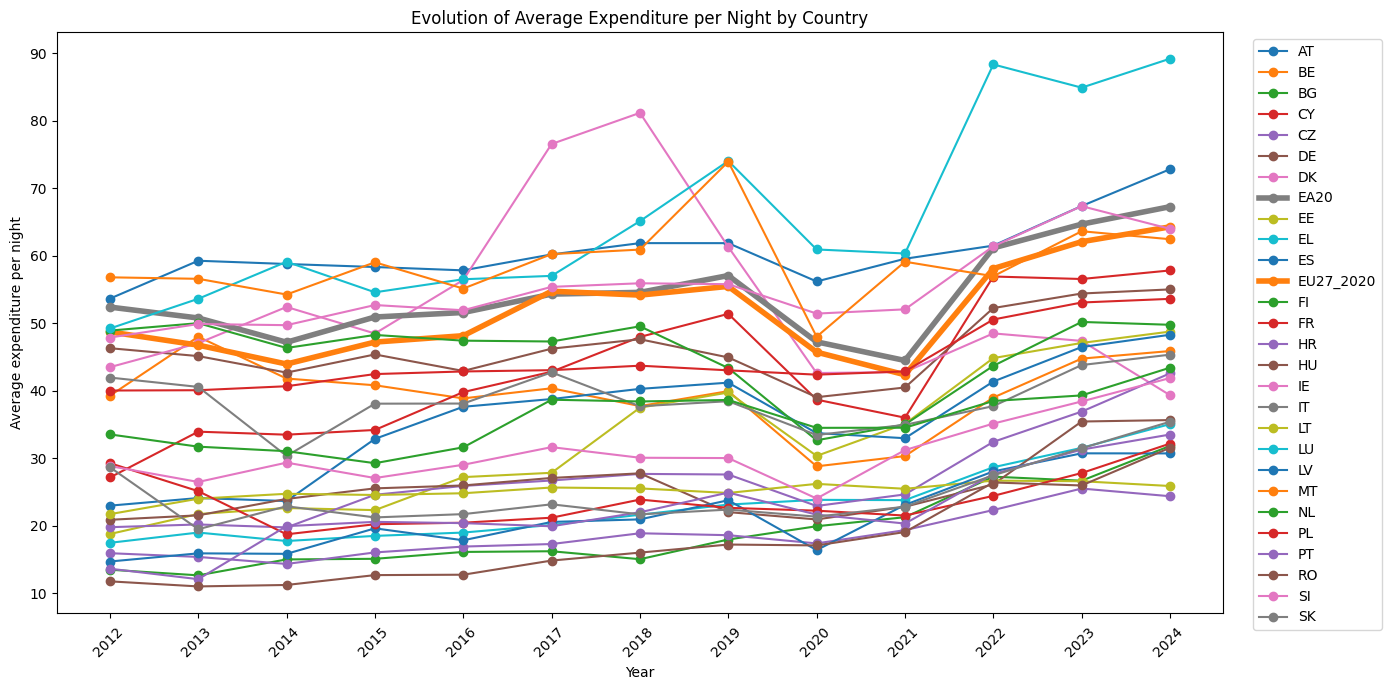

In [38]:
# Average expenditure per night by country per
avg_expenditure_night = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_NGT']
avg_spending_per_country = avg_expenditure_night.groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))

highlighted_countries = ['EA20', 'EU27_2020']

for country in avg_spending_per_country.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country.columns,
            avg_spending_per_country.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            avg_spending_per_country.columns,
            avg_spending_per_country.loc[country],
            alpha=1,
            marker="o",
            label=country
        )

plt.title("Evolution of Average Expenditure per Night by Country")
plt.xlabel("Year")
plt.ylabel("Average expenditure per night")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

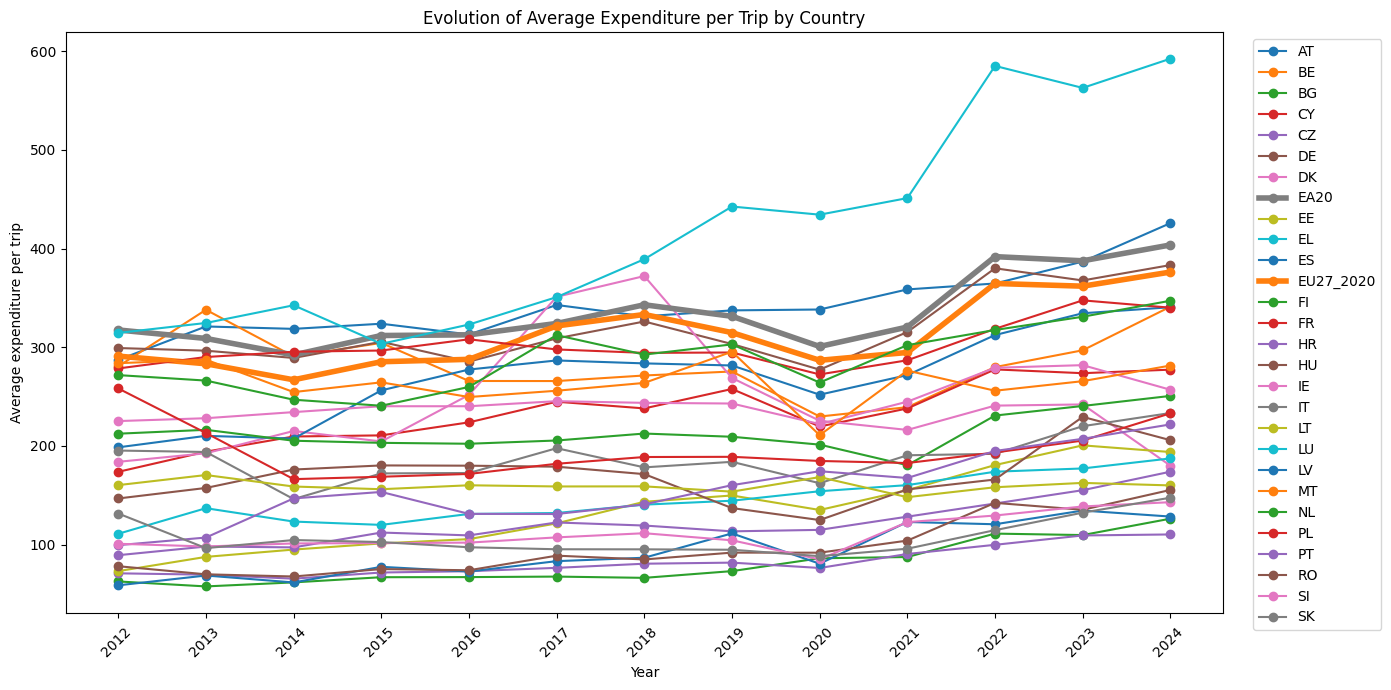

In [ ]:
# Average expenditure per trip by country
avg_expenditure_trip = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_TRP']
avg_spending_per_country_trip = avg_expenditure_trip.groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in avg_spending_per_country_trip.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

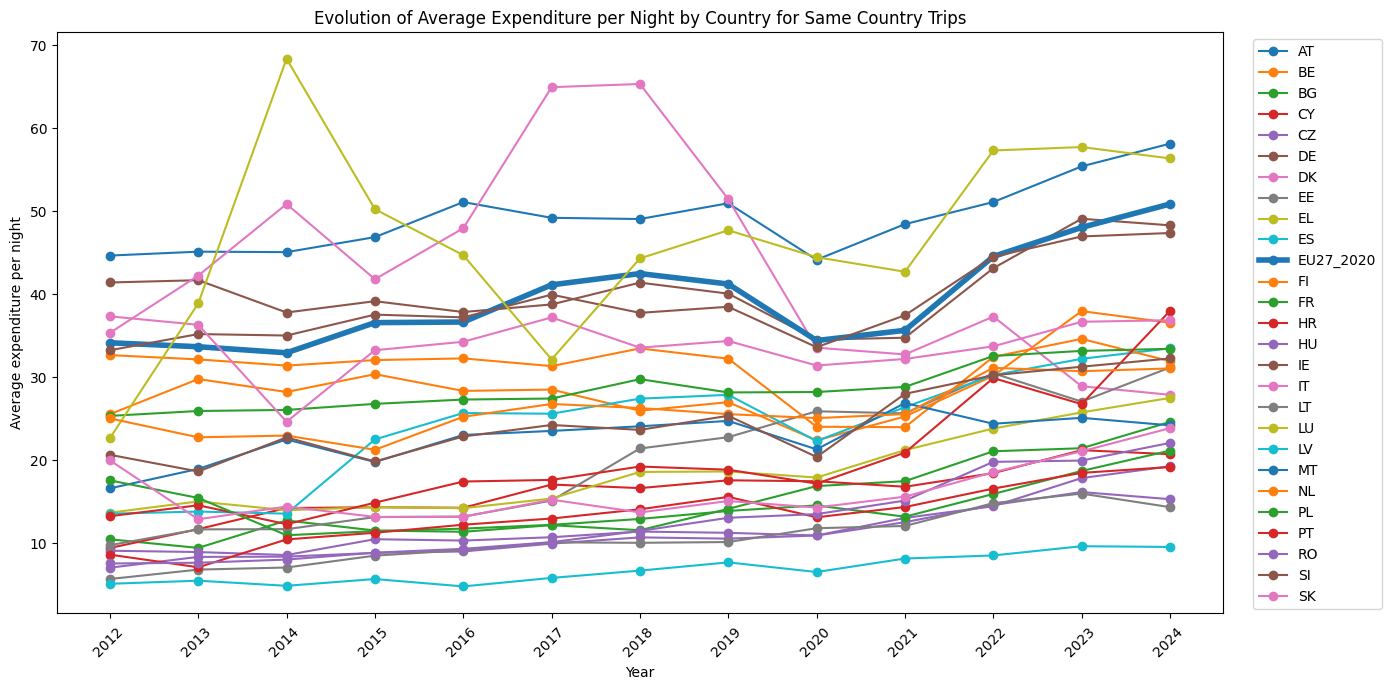

In [40]:
same_country_stats = extotw_cleaned[(extotw_cleaned['geo'] == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_NGT')].groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in same_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for Same Country Trips")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per night")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

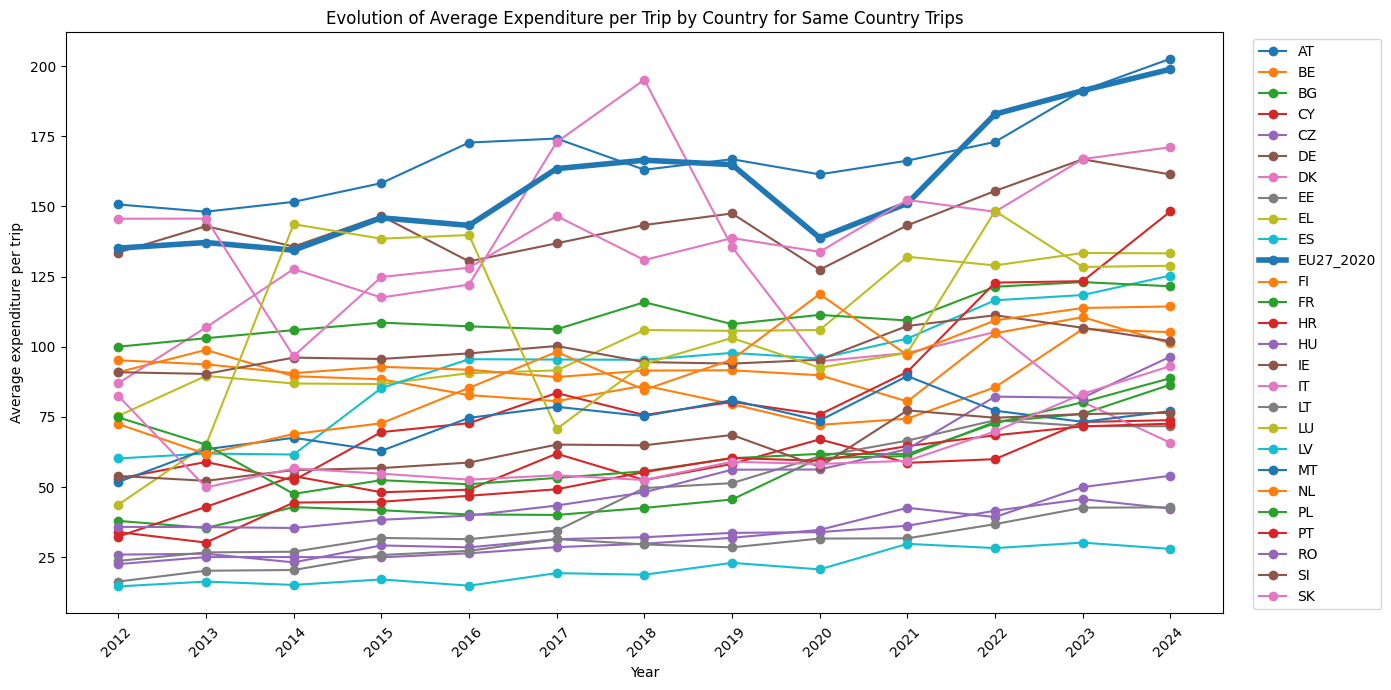

In [41]:
same_country_stats = extotw_cleaned[(extotw_cleaned['geo'] == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in same_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country for Same Country Trips")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

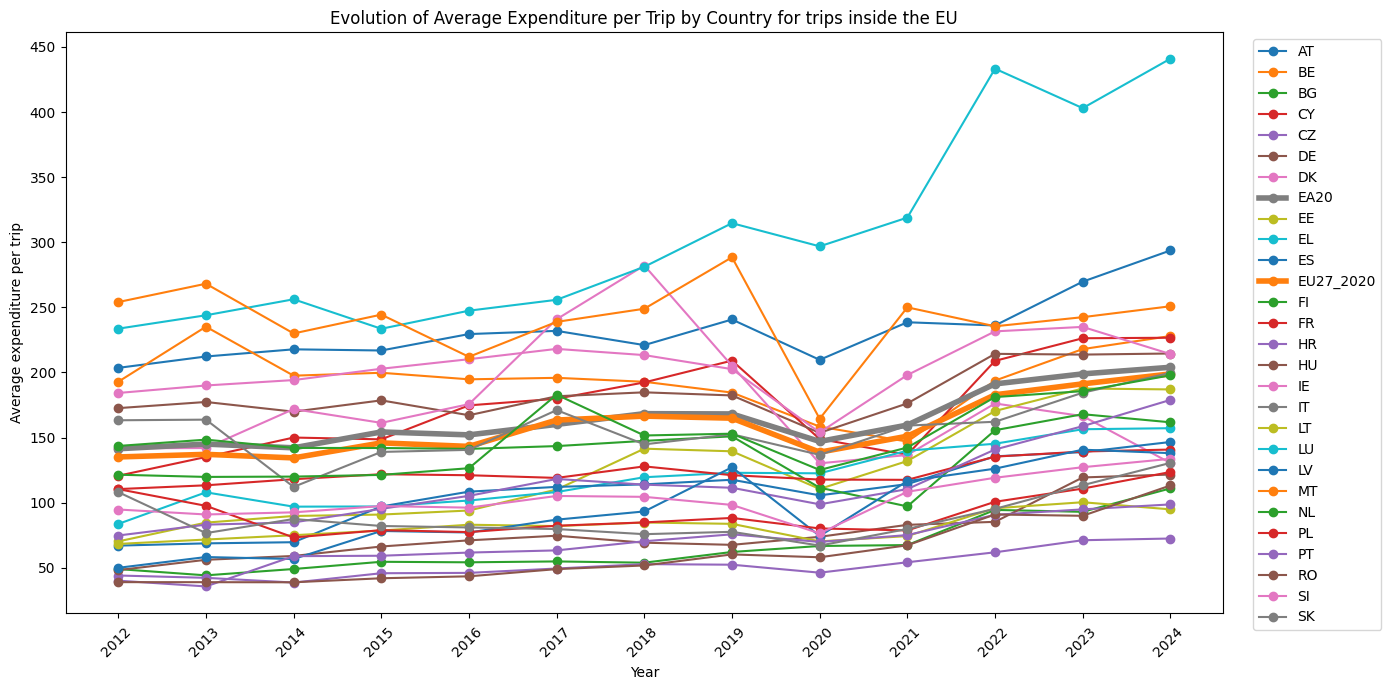

In [43]:
# Average expenditure per trip by country Inside the EU
in_EU_country_stats = extotw_cleaned[('EU27_2020' == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in in_EU_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            in_EU_country_stats.columns,
            in_EU_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            in_EU_country_stats.columns,
            in_EU_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country for trips inside the EU")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


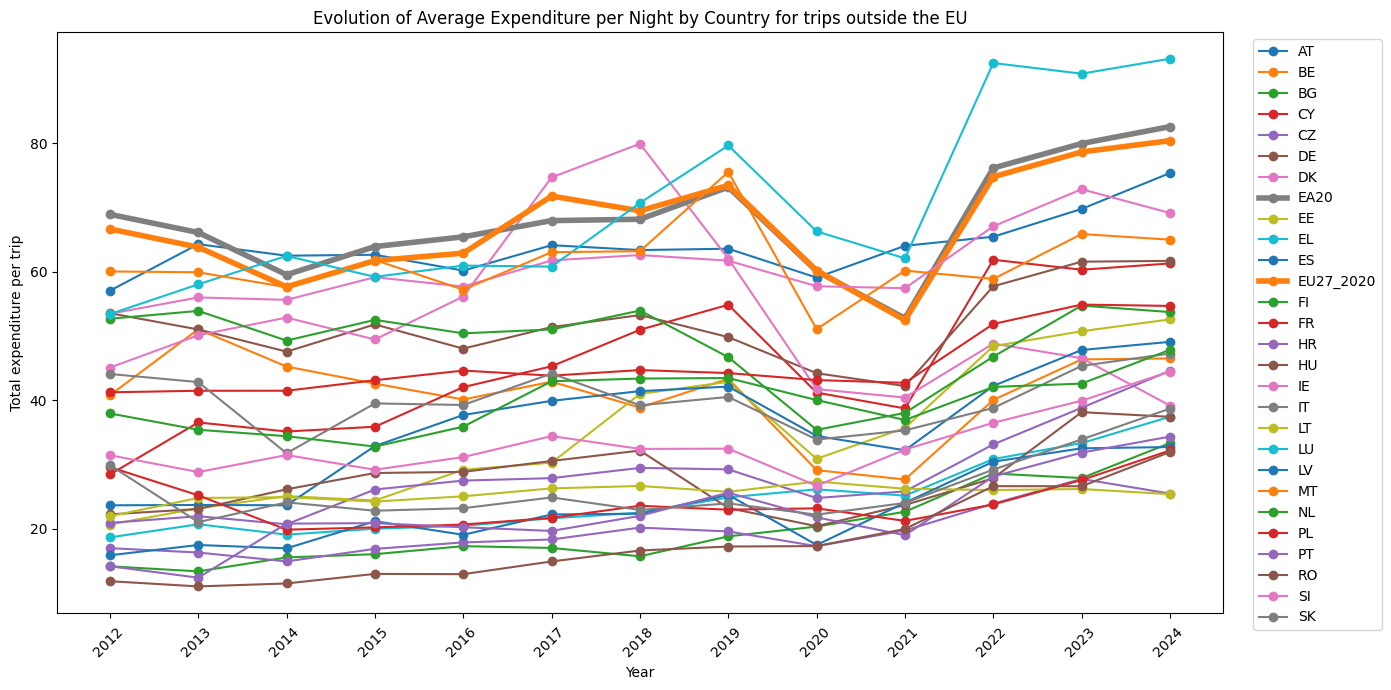

In [52]:
# Total expenditure per trip by country Inside the EU
out_EU_country_stats_avg_ngt = extotw_cleaned[(extotw_cleaned['c_dest'].isin(eu_countries) == False) & (extotw_cleaned['statinfo'] == 'AVG_NGT')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in out_EU_country_stats_avg_ngt.index:
    if country in highlighted_countries:
        plt.plot(
            out_EU_country_stats_avg_ngt.columns,
            out_EU_country_stats_avg_ngt.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            out_EU_country_stats_avg_ngt.columns,
            out_EU_country_stats_avg_ngt.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for trips outside the EU")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

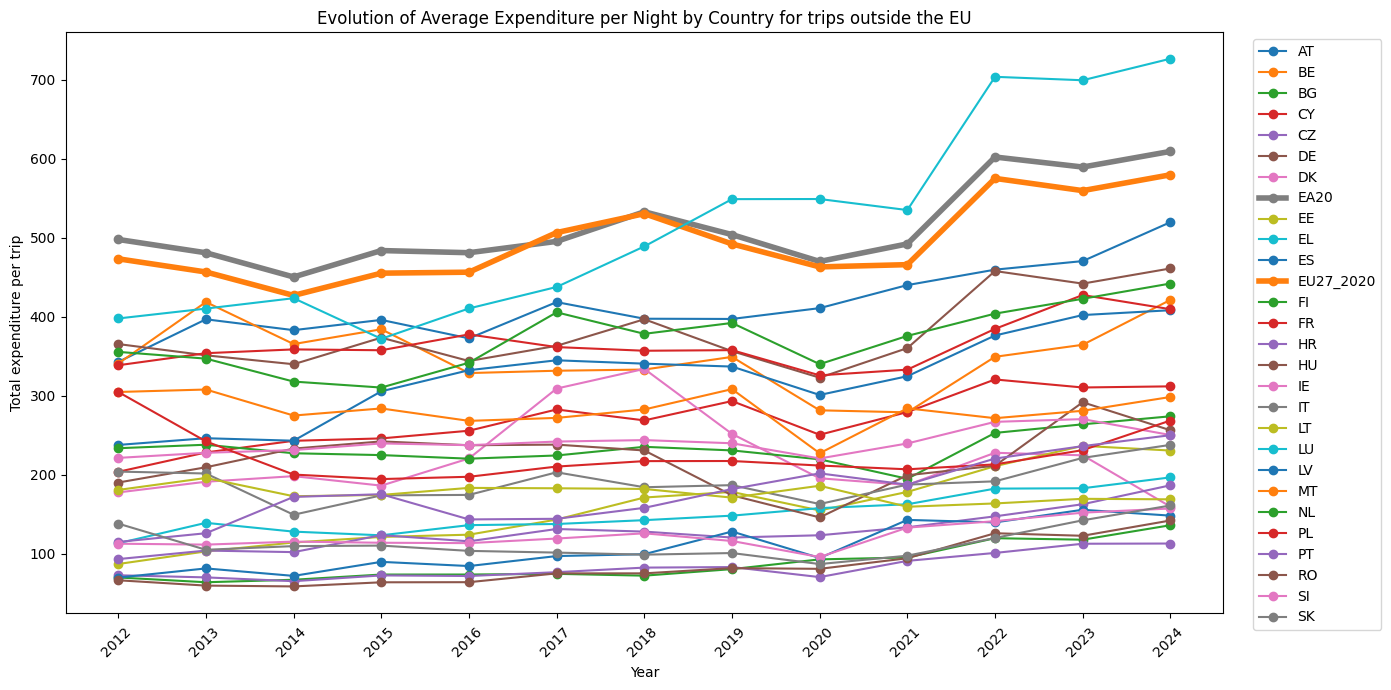

In [56]:
# Total expenditure per trip by country Inside the EU
out_EU_per_trip = extotw_cleaned[(extotw_cleaned['c_dest'].isin(eu_countries) == False) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in out_EU_per_trip.index:
    if country in highlighted_countries:
        plt.plot(
            out_EU_per_trip.columns,
            out_EU_per_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            out_EU_per_trip.columns,
            out_EU_per_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for trips outside the EU")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

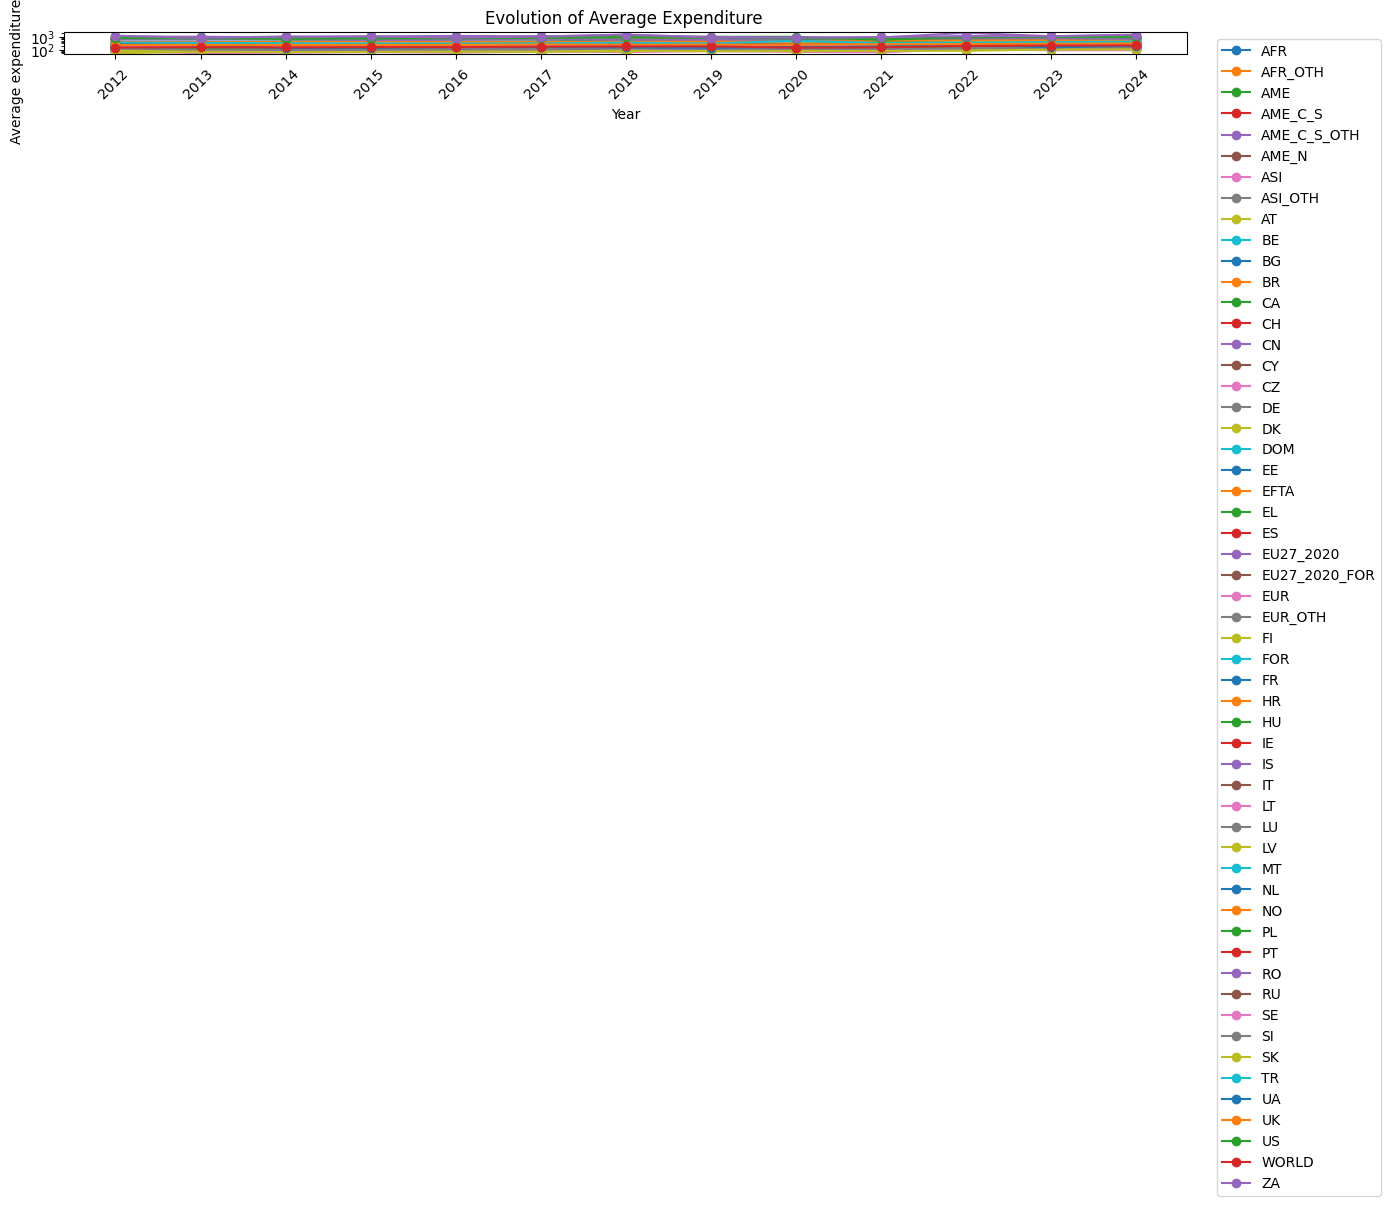

In [58]:
# Average expenditure in the destination country per trip by country
avg_expenditure_trip = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_TRP']
avg_spending_per_country_trip = avg_expenditure_trip.groupby('c_dest')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = []
for country in avg_spending_per_country_trip.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure ")
plt.yscale('log')
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [98]:
# Most popular Accomodation overall per year
banned_values =['TOTAL', 'TOT_R', 'TOT_NR']
total_values_by_accomod = tnac_cleaned[tnac_cleaned['accommod'] == 'TOTAL'].groupby('geo')[years_tnac].sum()
accomad_per_year = tnac_cleaned[~tnac_cleaned['accommod'].isin(banned_values)].groupby('accommod')[years_tnac].sum()
percentage_accomad_per_year = accomad_per_year.div(total_values_by_accomod.sum(axis=0), axis=1) * 100
percentage_accomad_per_year

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
accommod,,,,,,,,,,,,,
NR_OTH,1.600440,1.635387,1.953067,1.820540,1.918580,1.946735,1.838863,2.114337,2.547862,2.430798,3.442096,3.260540,2.356096
NR_OWN,13.073564,13.109455,12.536885,11.476785,11.852222,13.069077,12.973123,13.090658,16.020869,14.090612,11.936685,11.384679,11.853311
NR_RF,32.259831,32.949289,33.046958,33.967506,32.463248,30.853620,29.572330,28.535164,35.475062,34.315351,28.242356,28.597087,27.375887
R_CAMP,5.808622,5.741808,5.749114,6.143742,5.705525,4.872158,5.439404,5.485658,6.012561,6.374232,6.103799,5.322042,5.790491
R_HOT,28.551424,27.681015,27.540677,27.618901,28.564200,29.698383,30.410852,30.727070,18.788609,20.883420,28.470696,29.446792,29.842575
R_OTH,17.032012,17.186958,17.341792,17.191304,17.640230,17.680782,17.799081,17.946718,4.179234,4.147506,4.406652,4.155287,4.247544


In [ ]:
# Most popular accomodation type by country

tnac_cleaned_accomod = tnac_cleaned.groupby(['geo', 'accommod'])[years_tnac].sum().reset_index()
tnac_cleaned_accomod.groupby('geo')[years_tnac].idxmax()

filtered_tnac = tnac_cleaned[~tnac_cleaned['accommod'].isin(banned_values)]
grouped = (
    tnac_cleaned
    .groupby(['geo', 'accommod'])[years_tnac]
    .sum()
    .reset_index()
)

most_popular_2024 = grouped.loc[
    grouped.groupby('geo')['2012'].idxmax(),
    ['geo', 'accommod', '2012']
].sort_values('geo')

most_popular_2024


KeyError: 'Column not found: 2012'

In [ ]:
# Per destination country, the most popular accomodation type